In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from sklearn import set_config

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
set_config(display="text")  # displays text representation of estimators

from sksurv.util import Surv
sys.path.append(os.path.abspath("../../"))
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.Preprocessing import Preprocessor
from src.utils.cox_models import Cox_regression, p_values_Cox_regression, plot_coefficients

%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
pp = Preprocessor()
cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)


<font size="4">Preprocessing</font>

In [4]:
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_df = pp.eliminate_zero_genes(df_mRNA_transformed, "Hugo_Symbol")

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)
Genes before: 20440
Genes after: 18540


Index(['Sample ID', 'expression', 'Hugo_Symbol'], dtype='object')


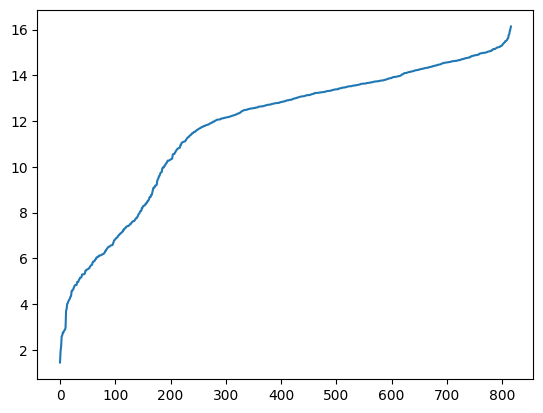

In [5]:
df_ESR1 = pp.gene_to_long(df_mRNA_transformed,"ESR1")
print(df_ESR1.columns)

expression = df_ESR1["expression"].values
lsit = list()
for i in expression:
    lsit.append(i)


lsit.sort()


plt.plot(np.log2(lsit)) # plotting by columns
plt.show()

In [8]:
X_ESR1, Y_surv_ESR1, df_gene_merged = pp.split_data_set(df_mRNA_transformed, df_clinical_keep, "ESR1")

In [9]:
X_train_ESR1, X_test_ESR1, Y_train_ESR1, Y_test_ESR1 = train_test_split(
    X_ESR1, Y_surv_ESR1, train_size=0.80, test_size=0.20, random_state=42
)
print(type(X_train_ESR1))

<class 'pandas.core.frame.DataFrame'>


In [10]:
betas_ESR1, chp_predict_ESR1, survival_curve_ESR1, risk_curve_ESR1 = Cox_regression(X_train_ESR1, Y_train_ESR1, X_test_ESR1)

In [11]:
print(betas_ESR1)
#Alpha is regularization 
#Low alpha == Low regularization
#Big alpha == Big regularization

#Espression == Betas 
#β > 0 → aumenta el riesgo
#β < 0 → reduce el riesgo
#β ≈ 0 → no hay efecto

alpha       0.00010      0.00015      0.00021      0.00031      0.00045      \
expression      0.00687      0.00687      0.00687      0.00687      0.00687   

alpha       0.00066      0.00095      0.00139      0.00202      0.00295      \
expression      0.00687      0.00687      0.00687      0.00687      0.00687   

alpha       ...  339.32218    494.17134    719.68567    1048.11313   \
expression  ...     0.004921     0.004358     0.003737     0.003095   

alpha       1526.41797   2222.99648   3237.45754   4714.86636   6866.48845   \
expression     0.002476     0.001918     0.001444     0.001062     0.000767   

alpha       10000.00000  
expression     0.000546  

[1 rows x 50 columns]


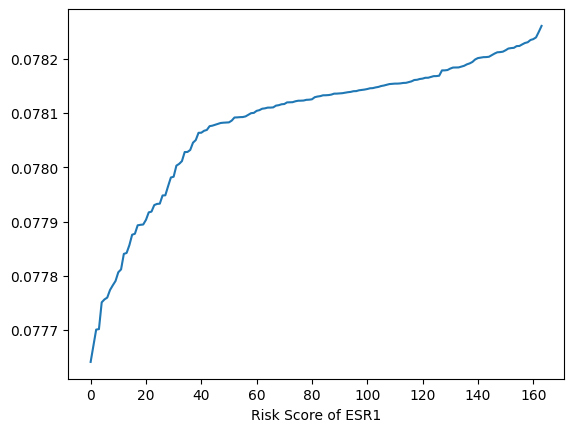

In [12]:
# Risk Score = Expression x β
# valor más alto → mayor riesgo relativo
#valor más bajo → menor riesgo relativo

#Sorteasa normalizas, (0-100)
lsit = sorted(chp_predict_ESR1)
exp_ = np.exp(lsit)
normalize = preprocessing.normalize([exp_])[0]
plt.plot(normalize)
plt.xlabel("Risk Score of ESR1")
plt.show()


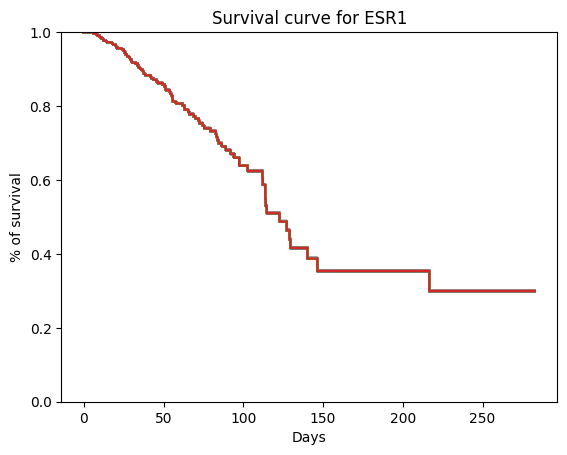

In [ ]:

for fn in survival_curve_ESR1:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for ESR1")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

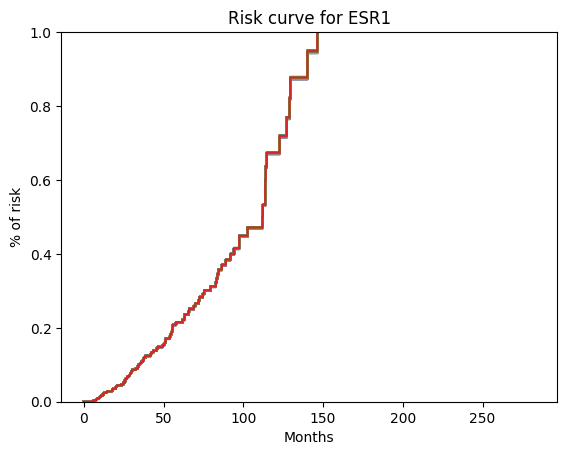

In [14]:
for fn in risk_curve_ESR1:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Risk curve for ESR1")
plt.xlabel("Months")
plt.ylim(0, 1)
plt.ylabel("% of risk")
plt.show()

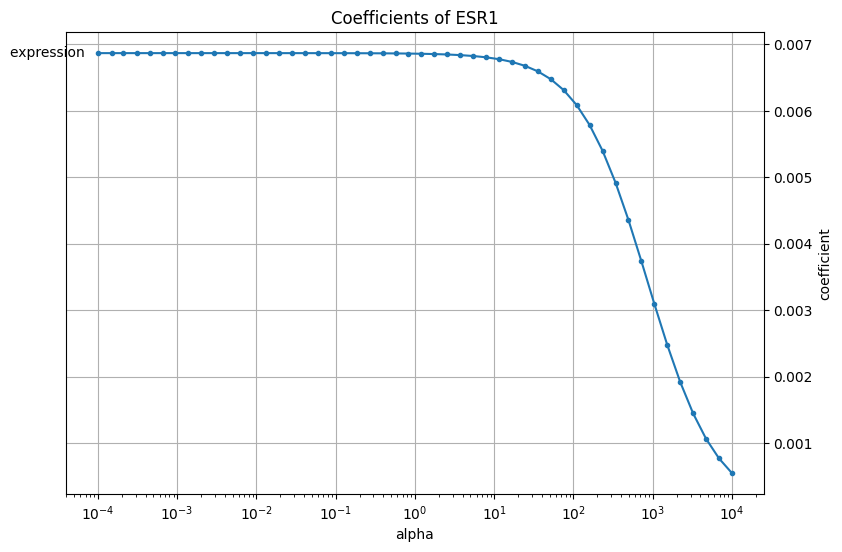

In [15]:
plot_coefficients(betas_ESR1, n_highlight=5, title="Coefficients of ESR1")

In [34]:
"""cox_lasso.fit(X_train_ESR1, X_test_ESR1)
coefficient_lasso = pd.DataFrame(cox_lasso.coef_, index=X.columns, columns=(cox_lasso.alphas_))
plot_coefficients(coefficient_lasso, n_highlight=5, title="ESR1 Coefficients")
cox_lasso.predict(X_test)
"""

'cox_lasso.fit(X_train_ESR1, X_test_ESR1)\ncoefficient_lasso = pd.DataFrame(cox_lasso.coef_, index=X.columns, columns=(cox_lasso.alphas_))\nplot_coefficients(coefficient_lasso, n_highlight=5, title="ESR1 Coefficients")\ncox_lasso.predict(X_test)\n'

In [16]:
df_life_line_ESR1 = df_gene_merged[["expression", "event", "Overall Survival (Months)"]]

In [17]:
df_life_line_ESR1 = df_gene_merged[
    ["expression", "event", "Overall Survival (Months)"]
].copy()

df_life_line_ESR1 = df_life_line_ESR1[
    df_life_line_ESR1["Overall Survival (Months)"] > 0
]

In [18]:
p_values_Cox_regression(df_life_line_ESR1,event_col="event", duration_col="Overall Survival (Months)")

#p_values = p
#p < 0.05 → hay evidencia de que la variable sí afecta la supervivencia
#p ≥ 0.05 → no hay evidencia suficiente
# p == 0.79 = No significativo

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,-0.001515,0.998487,0.030893,-0.062063,0.059034,0.939823,1.060812,0.0,-0.049028,0.960897,0.057546


<font size="4">AURKA coefficients and p_values</font>

In [33]:
df_AURKA = pp.gene_to_long(clean_df, "AURKA")

In [34]:
df_AURKA_merged = df_AURKA.merge(df_clinical_keep, on="Sample ID", how="inner")
status = df_AURKA_merged["Overall Survival Status"].astype(str).str.strip()
df_AURKA_merged["event"] = status.str.contains("DECEASED", na=False) 
df_AURKA_merged = df_AURKA_merged.dropna(subset=["Overall Survival (Months)"])
X_AURKA = df_AURKA_merged[["expression"]]
Y_surv_AURKA = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=df_AURKA_merged
)

In [35]:
X_train_AURKA, X_test_AURKA, Y_train_AURKA, Y_test_AURKA = train_test_split(
    X_AURKA, Y_surv_AURKA, train_size=0.80, test_size=0.20, random_state=42
)


In [36]:
betas_AURKA, chp_predict_AURKA, survival_curve_AURKA, risk_curve_AURKA = Cox_regression(X_train_AURKA, Y_train_AURKA, X_test_AURKA)

In [37]:
print(betas_AURKA)
#Alpha is regularization 
#Low alpha == Low regularization
#Big alpha == Big regularization

#Espression == Betas 
#β > 0 → aumenta el riesgo
#β < 0 → reduce el riesgo
#β ≈ 0 → no hay efecto

alpha       0.00010      0.00015      0.00021      0.00031      0.00045      \
expression    -0.000002    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       0.00066      0.00095      0.00139      0.00202      0.00295      \
expression    -0.000002    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       ...  339.32218    494.17134    719.68567    1048.11313   \
expression  ...    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       1526.41797   2222.99648   3237.45754   4714.86636   6866.48845   \
expression    -0.000002    -0.000002    -0.000002    -0.000002    -0.000002   

alpha       10000.00000  
expression    -0.000002  

[1 rows x 50 columns]


In [40]:
print(chp_predict_AURKA)

# Risk Score = Expression x β
# valor más alto → mayor riesgo relativo
#valor más bajo → menor riesgo relativo

lsit = list()
for i in chp_predict_AURKA:
    lsit.append(i)

lsit.sort()

lsit_np = np.exp(lsit)
lsit_np


[-0.00045987 -0.0004478  -0.00019214 -0.00607356 -0.00084914 -0.00040606
 -0.00073634 -0.00205469 -0.00098431 -0.00238117 -0.00026114 -0.00180553
 -0.00394049 -0.00213995 -0.00066283 -0.00053252 -0.00019059 -0.00076849
 -0.00075041 -0.00027709 -0.0012484  -0.00022339 -0.00096148 -0.00077469
 -0.00082735 -0.01061253 -0.00158266 -0.00035362 -0.00029002 -0.00075467
 -0.00056744 -0.00042991 -0.00034457 -0.00030638 -0.00033971 -0.00047915
 -0.00153606 -0.00072167 -0.0002831  -0.00119987 -0.00162013 -0.00034287
 -0.00021992 -0.0003489  -0.00100304 -0.00121767 -0.00051698 -0.00021624
 -0.00212328 -0.00028243 -0.0009641  -0.00115347 -0.00042838 -0.00044249
 -0.00030309 -0.00020911 -0.00144787 -0.00160348 -0.00247449 -0.00042643
 -0.00018601 -0.00070478 -0.00109137 -0.00093831 -0.00049647 -0.00167278
 -0.00063754 -0.00322842 -0.00106687 -0.00073187 -0.00151405 -0.00147096
 -0.00078492 -0.00075083 -0.00100438 -0.00044379 -0.00027774 -0.00042804
 -0.00251505 -0.00287978 -0.00436221 -0.00310464 -0

array([0.98944358, 0.99394485, 0.99564729, 0.99606727, 0.99677679,
       0.99690017, 0.99712436, 0.99718048, 0.99738486, 0.99748811,
       0.99751242, 0.99752857, 0.99762166, 0.99786234, 0.99787897,
       0.99794742, 0.9981961 , 0.99827602, 0.99832862, 0.99838118,
       0.99839781, 0.9984186 , 0.99846512, 0.9984871 , 0.99853012,
       0.99855318, 0.99875238, 0.99878308, 0.99880085, 0.99884719,
       0.99890923, 0.9989337 , 0.99899612, 0.99899746, 0.99901618,
       0.99903637, 0.99903898, 0.99906213, 0.99915122, 0.999173  ,
       0.99921539, 0.99922561, 0.99923181, 0.99924562, 0.99924945,
       0.99924987, 0.99926393, 0.99926839, 0.99927859, 0.99928423,
       0.99929546, 0.99933739, 0.99936266, 0.99941501, 0.99943272,
       0.99946762, 0.99948316, 0.99950365, 0.99952097, 0.99954024,
       0.9995523 , 0.99955631, 0.99955761, 0.99957019, 0.99957171,
       0.99957205, 0.99957366, 0.99959403, 0.99962172, 0.99964644,
       0.99964645, 0.99965116, 0.99965549, 0.99965719, 0.99966

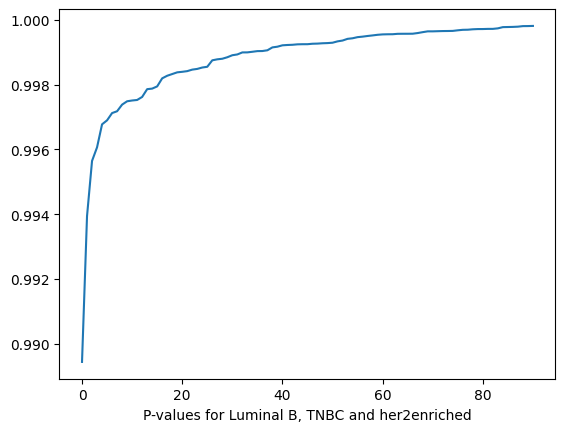

In [41]:
plt.plot(lsit_np) # plotting by columns
plt.xlabel("P-values for Luminal B, TNBC and her2enriched")
plt.show()

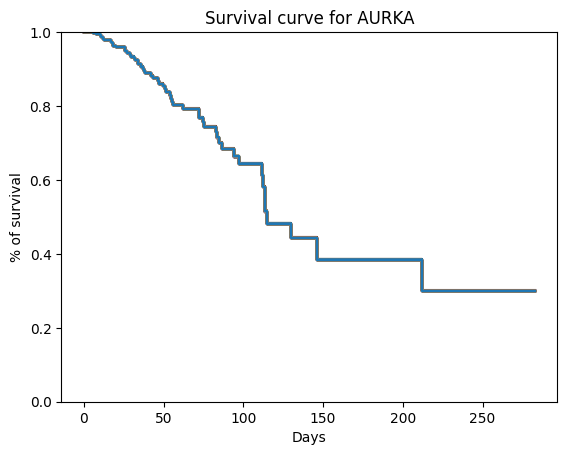

In [22]:
for fn in survival_curve_AURKA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for AURKA")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

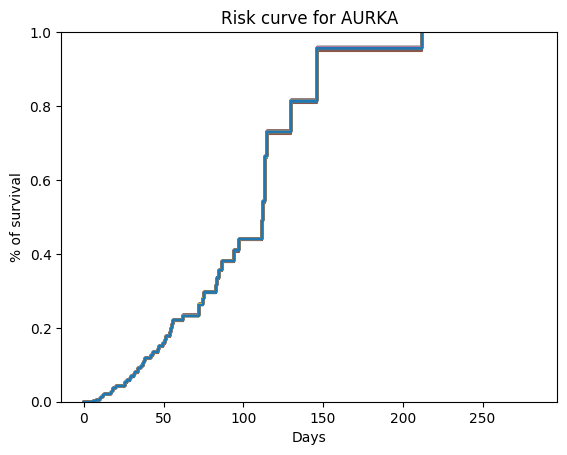

In [23]:
for fn in risk_curve_AURKA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Risk curve for AURKA")
plt.ylim(0, 1)
plt.xlabel("Days")
plt.ylabel("% of survival")
plt.show()

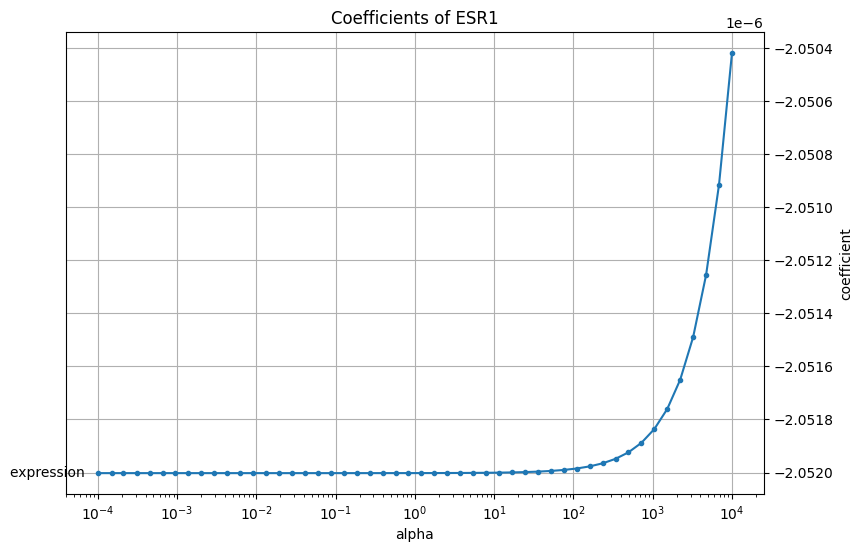

In [24]:
plot_coefficients(betas_AURKA, n_highlight=5, title="Coefficients of ESR1")

In [25]:
df_life_line_AURKA = df_AURKA_merged[["expression", "event", "Overall Survival (Months)"]]

In [26]:
p_values_Cox_regression(df_life_line_AURKA,event_col="event", duration_col="Overall Survival (Months)")

#p_values = p
#p < 0.05 → hay evidencia de que la variable sí afecta la supervivencia
#p ≥ 0.05 → no hay evidencia suficiente
# p == 0.61 = No significativo

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
expression,0.000123,1.000123,0.000247,-0.000362,0.000607,0.999638,1.000607,0.0,0.495879,0.61998,0.689706


<font size="4">Luminal A betas and p_values</font>

In [40]:
pp = Preprocessor()
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_keep = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_keep)
df_clinical_keep["Tumor-Cancer"] = list_df
df_mRNA_transformed = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
df_merged = pp.merge_datasets(df_clinical_keep, df_mRNA_transformed)

Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [41]:
expressions_genes_cols = df_merged.iloc[1:20441].sample(650, axis="columns")
cols = ["Tumor-Cancer", "Overall Survival Status", "Overall Survival (Months)"] + list(expressions_genes_cols)

comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
    cols
]

In [42]:
comparation_df = pp.elimnation_zeros(comparation_df, "Tumor-Cancer")

Max of zeros per row in the dataset: 519
Avg of zeros per row in the dataset: 84.71472392638037
Median of zeros per row in the dataset: 0.0
Min of zeros per row in the dataset: 0
After the 0 elimination: 510


In [43]:
luminal_A_df = comparation_df[comparation_df["Tumor-Cancer"] == "Luminal A"]
status = luminal_A_df["Overall Survival Status"].astype(str).str.strip()
luminal_A_df["event"] = status.str.contains("DECEASED", na=False) 
luminal_A_df = luminal_A_df.dropna(subset=["Overall Survival (Months)"])
X_LUMINAL_A = luminal_A_df.iloc[:, 3:-1]
Y_surv_LUMINAL_A = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=luminal_A_df
)

In [44]:

X_train_LuminalA, X_test_LuminalA,Y_train_LuminalA,Y_test_LuminalA = train_test_split(
    X_LUMINAL_A, Y_surv_LUMINAL_A, train_size=0.80, test_size=0.20, random_state=42
)
    

In [45]:
#Need CPU power 
betas_LuminalA, chp_predict_LuminalA, survival_curve_LuminalA, risk_curve_LuminalA = Cox_regression(X_train_LuminalA, Y_train_LuminalA, X_test_LuminalA)

TypeError: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.

In [32]:
for fn in survival_curve_LuminalA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for ESR1")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

NameError: name 'survival_curve_LuminalA' is not defined

In [46]:
for fn in risk_curve_LuminalA:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for Luminal A")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

NameError: name 'risk_curve_LuminalA' is not defined

In [47]:
expressions_luminal_A = luminal_A_df.iloc[:, 3:-1]

In [48]:
p_values_luminalA = []
for i, sample in enumerate(expressions_luminal_A.columns):
    df_life_line_sample = luminal_A_df[
        [sample, "event", "Overall Survival (Months)"]
    ]
    p_values_luminalA.append(p_values_Cox_regression(df_life_line_sample,event_col="event", duration_col="Overall Survival (Months)"))

    if i > 50:
        break 

In [49]:
df_final_luminal_A = pd.concat(p_values_luminalA)

df_final_luminal_A[["coef","exp(coef)", "exp(coef)","z", "p"]]

array_luminal_a = np.asarray(df_final_luminal_A["p"])


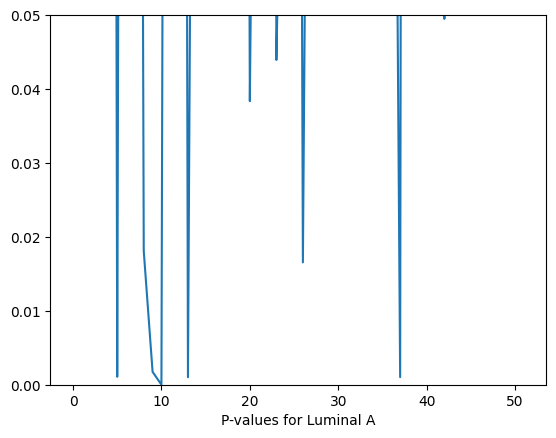

In [51]:
plt.plot(array_luminal_a) # plotting by columns
plt.xlabel("P-values for Luminal A")
plt.ylim(0.00, 0.05)
plt.show()

<font size="4">Luminal B, TNBC, Her-Enriched2 betas and p_values</font>

In [38]:
diff_subtypes_df = comparation_df[comparation_df["Tumor-Cancer"] != "Luminal A"]
status = diff_subtypes_df["Overall Survival Status"].astype(str).str.strip()
diff_subtypes_df["event"] = status.str.contains("DECEASED", na=False) 
diff_subtypes_df = diff_subtypes_df.dropna(subset=["Overall Survival (Months)"])
X_diff_subtypes = diff_subtypes_df.iloc[:, 3:-1]
Y_surv_subtypes = Surv.from_dataframe(
    event="event",
    time="Overall Survival (Months)",
    data=diff_subtypes_df
)

In [39]:

X_train_subtypes, X_test_subtypes,Y_train_subtypes,Y_test_subtypes = train_test_split(
    X_diff_subtypes, Y_surv_subtypes, train_size=0.80, test_size=0.20, random_state=42
)

In [ ]:
#Need CPU power
betas_subtypes, chp_predict_subtypes, survival_curve_subtypes, risk_curve_subtypes = Cox_regression(X_train_subtypes, Y_train_subtypes, X_test_subtypes)

KeyboardInterrupt: 

In [ ]:
for fn in survival_curve_subtypes:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Survival curve for Luminal B, TNBC, HerEnriched2")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

In [ ]:
for fn in risk_curve_subtypes:
    plt.step(fn.x, fn(fn.x), where="post")

plt.title("Risk curve for Luminal B, TNBC, HerEnriched2")
plt.xlabel("Days")
plt.ylim(0, 1)
plt.ylabel("% of survival")
plt.show()

In [41]:
expressions_not_luminalA = diff_subtypes_df.iloc[:, 3:-1]

In [42]:
p_values_not_luminalA = []
for i, sample in enumerate(expressions_not_luminalA.columns):
    df_line_sample_not_luminalA = diff_subtypes_df[
        [sample, "event", "Overall Survival (Months)"]
    ]
    
    p_values_not_luminalA.append(p_values_Cox_regression(df_line_sample_not_luminalA, event_col="event", duration_col="Overall Survival (Months)"))
    
    if i >= 50:
        break
    

In [43]:
df_final_not_luminal_A = pd.concat(p_values_not_luminalA)

df_final_not_luminal_A[["coef","exp(coef)", "exp(coef)","z", "p"]]

p_values = df_final_not_luminal_A["p"]

array_p_values = np.asarray(p_values)

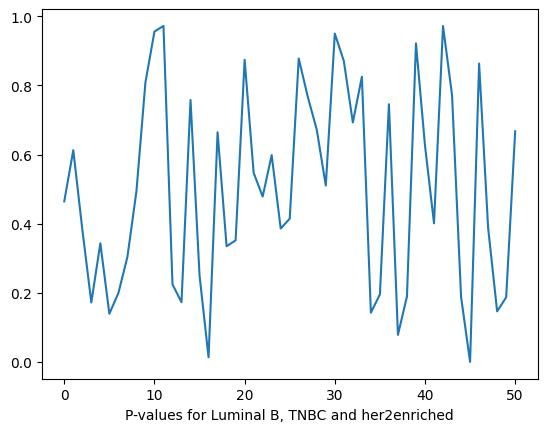

In [45]:
plt.plot(array_p_values) # plotting by columns
plt.xlabel("P-values for Luminal B, TNBC and her2enriched")
plt.show()